In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/311_requests.csv",  sep=";")

In [4]:
type = (df.groupby(["Service request type", "Department"]).size().sort_values(ascending=False).head(25))
print(type)

Service request type                    Department                                        
Building and Development Inquiry Case   DBL - Services Centre                                 108522
Business Licence Request Case           DBL - Licence Office                                   66592
Missed Green Bin Pickup Case            ENG - Sanitation Services                              58294
Garbage Bin Request Case                ENG - Sanitation Services                              54128
City and Park Trees Maintenance Case    PR - Urban Forestry                                    47322
Missed Garbage Bin Pickup Case          ENG - Sanitation Services                              43362
Mayor and Council Feedback Case         CMO - Business and Election Services                   42973
Abandoned Non-Recyclables-Small Case    ENG - Sanitation Services                              39186
Green Bin Request Case                  ENG - Sanitation Services                              31557


In [7]:
df.head()

,Department,Service request type,Status,Closure reason,Service request open timestamp,Service request close date,Last modified timestamp,Address,Local area,Channel,Latitude,Longitude,geom
0,ENG - Sanitation Services,Missed Green Bin Pickup Case,Close,Service provided,2023-07-21T20:19:00-07:00,2023-07-25,2023-07-25T06:46:48-07:00,NaN,Kensington-Cedar Cottage,Phone,NaN,NaN,NaN
1,ENG - Waterworks Design,Water Conservation Violation Case,Close,Service provided,2023-07-21T20:20:54-07:00,2023-07-31,2023-07-31T09:37:55-07:00,NaN,Victoria-Fraserview,Mobile App,NaN,NaN,NaN
2,ENG - Sanitation Services,Missed Garbage Bin Pickup Case,Close,Service provided,2023-07-21T20:22:18-07:00,2023-07-25,2023-07-25T06:41:49-07:00,NaN,Grandview-Woodland,WEB,NaN,NaN,NaN
3,ENG - Sanitation Services,Abandoned Mattress Case,Close,Service provided,2023-07-21T20:29:33-07:00,2023-08-09,2023-08-09T11:33:41-07:00,1126 BARCLAY ST,West End,Mobile App,49.283776,-123.128424,"49.28377550662, -123.1284237372"
4,ENG - Streets Operations,Street Repair Case,Close,Further action has been planned,2023-07-21T20:44:43-07:00,2023-07-27,2023-07-27T14:46:22-07:00,787 BEATTY ST,Downtown,WEB,49.277639,-123.113990,"49.27763911193, -123.11399013327"


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188429 entries, 0 to 1188428
Data columns (total 13 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Department                      1188429 non-null  object 
 1   Service request type            1188429 non-null  object 
 2   Status                          1188429 non-null  object 
 3   Closure reason                  1171376 non-null  object 
 4   Service request open timestamp  1188429 non-null  object 
 5   Service request close date      1171176 non-null  object 
 6   Last modified timestamp         1188429 non-null  object 
 7   Address                         401992 non-null   object 
 8   Local area                      928652 non-null   object 
 9   Channel                         1188429 non-null  object 
 10  Latitude                        399112 non-null   float64
 11  Longitude                       399112 non-null   float64
 12  

In [12]:
df.columns

Index(['Department', 'Service request type', 'Status', 'Closure reason',
       'Service request open timestamp', 'Service request close date',
       'Last modified timestamp', 'Address', 'Local area', 'Channel',
       'Latitude', 'Longitude', 'geom'],
      dtype='object')

In [13]:
print(df.describe())

            Latitude      Longitude
count  399112.000000  399112.000000
mean       49.256893    -123.103595
std         0.023067       0.043340
min        49.098380    -123.385073
25%        49.239744    -123.133832
50%        49.261321    -123.102961
75%        49.276658    -123.069188
max        49.314098    -123.015160


In [ ]:

print(df.isnull().sum())

Department                             0
Service request type                   0
Status                                 0
Closure reason                     17053
Service request open timestamp         0
Service request close date         17253
Last modified timestamp                0
Address                           786437
Local area                        259777
Channel                                0
Latitude                          789317
Longitude                         789317
geom                              789317
dtype: int64


In [17]:
df.shape

(1188429, 13)

In [6]:
#change open timestamp into datetime 
df["Service request open timestamp"] = pd.to_datetime(
    df["Service request open timestamp"],
    utc=True
)
print(df["Service request open timestamp"].dtype)

datetime64[ns, UTC]


In [7]:
# extract date only (this only works with 'datetime' feilds)
df["date"] = df["Service request open timestamp"].dt.date

In [8]:
# remove all rows with no local area info
df = df.dropna(subset=["Local area"])

In [9]:
# get the number of requests per day and par local area (group by both date and Local area)
daily_demand = (
    df.groupby(["date", "Local area"])
      .size()
      .reset_index(name="request_count")
)

                    Service request type  request_count
0  Building and Development Inquiry Case          95408
1           Missed Green Bin Pickup Case          57132
2   City and Park Trees Maintenance Case          45429
3         Missed Garbage Bin Pickup Case          42468
4   Abandoned Non-Recyclables-Small Case          37132
5          Business Licence Request Case          35915
6               Garbage Bin Request Case          32144
7                 Green Bin Request Case          30954
8       Parking Enforcement Request Case          26589
9            City Services Feedback Case          24714


<Axes: >

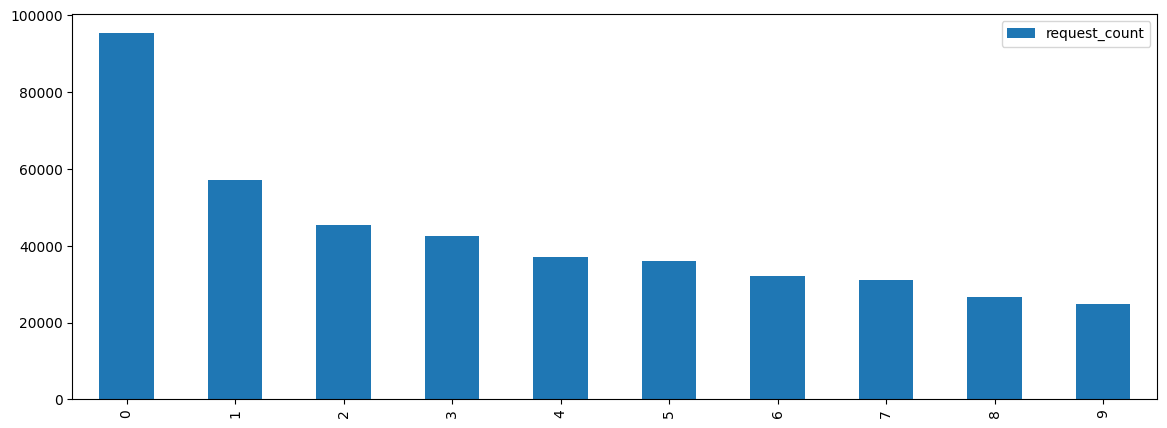

In [62]:
type = (
    df.groupby(["Service request type"])
      .size()
      .sort_values(ascending=False)
      .reset_index(name="request_count")
      .head(10)
  
    

      
)
print(type)
type.plot(
      kind="bar",
    figsize=(14,5))

In [32]:
print(daily_demand)

             date           Local area  request_count
0      2022-01-01        Arbutus Ridge              2
1      2022-01-01             Downtown             12
2      2022-01-01    Dunbar-Southlands              2
3      2022-01-01             Fairview              7
4      2022-01-01   Grandview-Woodland              8
...           ...                  ...            ...
34862  2026-05-14           Strathcona              3
34863  2026-05-14               Sunset             17
34864  2026-05-14  Victoria-Fraserview              7
34865  2026-05-14             West End              7
34866  2026-05-14      West Point Grey              3

[34867 rows x 3 columns]


<Axes: xlabel='date'>

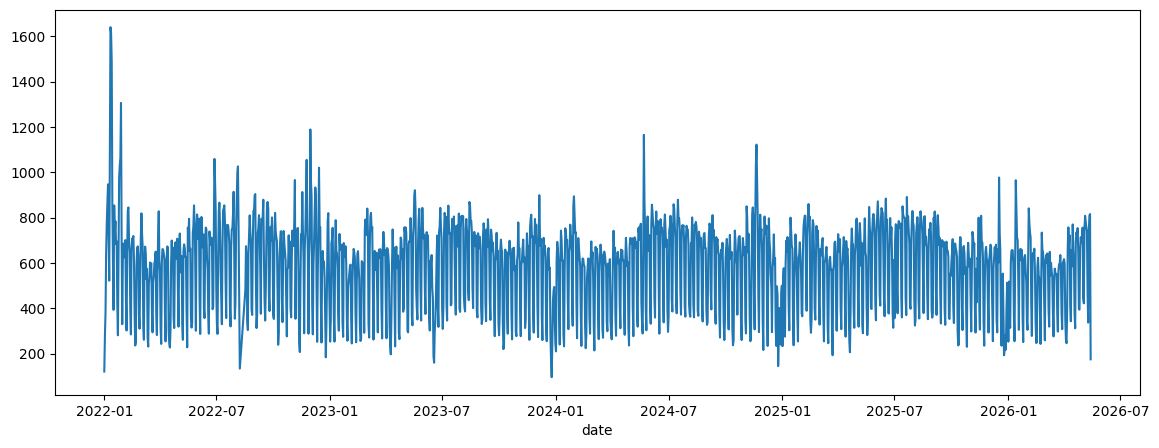

In [56]:
citywide = (
    daily_demand.groupby("date")["request_count"]
    .sum()
)

citywide.plot(

    figsize=(14,5))

In [11]:

    
area_counts = daily_demand.groupby("Local area")["request_count"].sum().sort_values(ascending=False)

print(area_counts)


Local area
Downtown                    102595
Kensington-Cedar Cottage     76475
Kitsilano                    62639
Renfrew-Collingwood          62014
Grandview-Woodland           56702
Mount Pleasant               53967
Hastings-Sunrise             53158
Sunset                       46581
West End                     43558
Riley Park                   43457
Fairview                     40559
Strathcona                   38563
Victoria-Fraserview          33915
Dunbar-Southlands            32984
Marpole                      32960
Killarney                    27771
West Point Grey              24586
Kerrisdale                   21848
Oakridge                     21052
Arbutus Ridge                19529
Shaughnessy                  17531
South Cambie                 16208
Name: request_count, dtype: int64


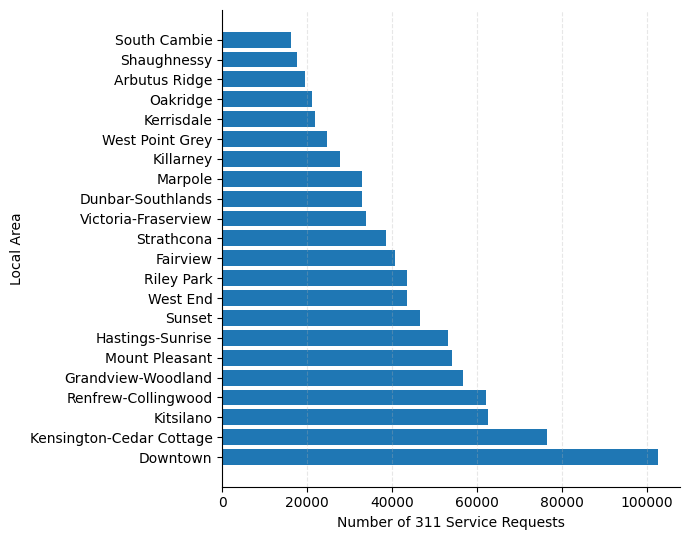

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5.5))

ax.barh(
    area_counts.index,
    area_counts.values
)

ax.set_xlabel("Number of 311 Service Requests")
ax.set_ylabel("Local Area")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "requests_by_area.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "requests_by_area.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

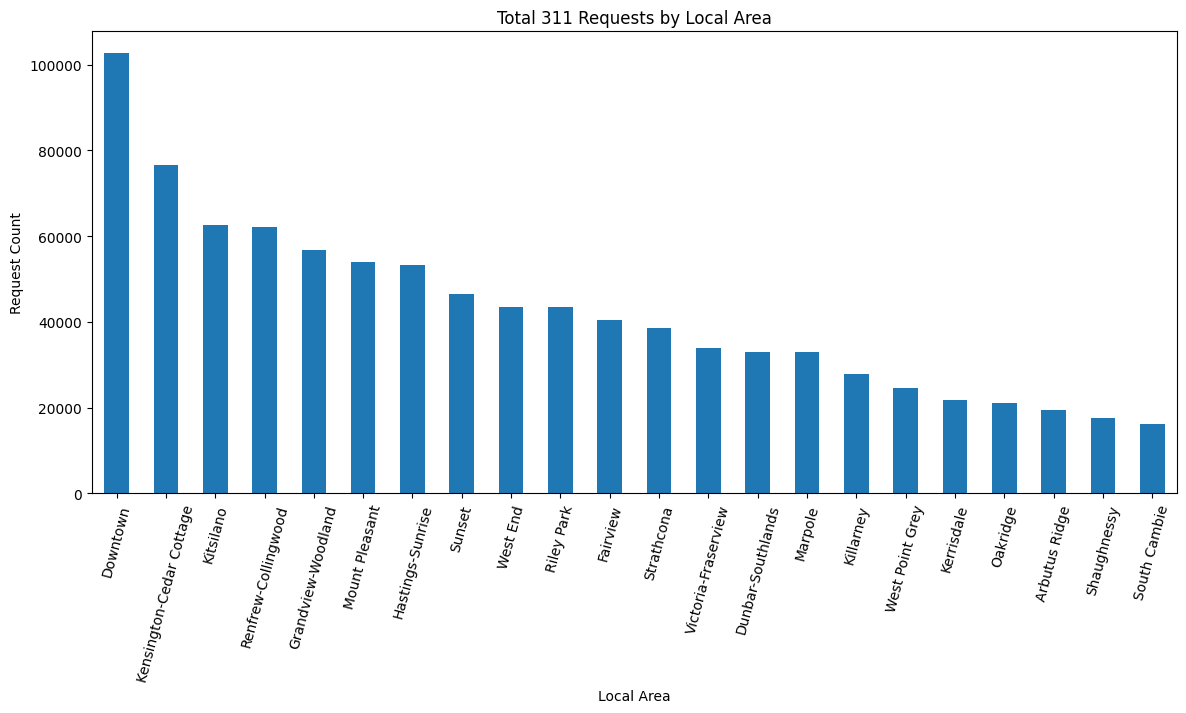

In [52]:
import matplotlib.pyplot as plt

area_counts.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Total 311 Requests by Local Area")
plt.ylabel("Request Count")
plt.xlabel("Local Area")

plt.xticks(rotation=75)

plt.show()

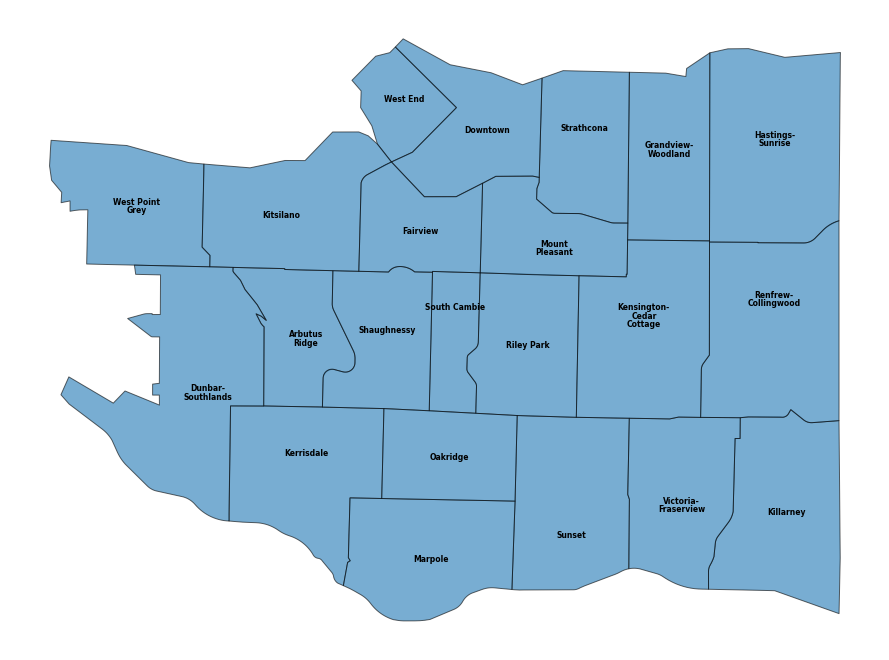

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import textwrap
import os

os.makedirs("figures", exist_ok=True)

url = "https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/local-area-boundary/exports/geojson?lang=en&timezone=America%2FLos_Angeles"

gdf = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.6
)

for _, row in gdf.iterrows():

    point = row.geometry.representative_point()

    label = "\n".join(
        textwrap.wrap(
            str(row["name"]),  # change column if needed
            width=12
        )
    )

    ax.annotate(
        text=label,
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=5.5,
        fontweight="bold",
        linespacing=0.9
    )

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    "figures/vancouver_local_areas_labeled.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/vancouver_local_areas_labeled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

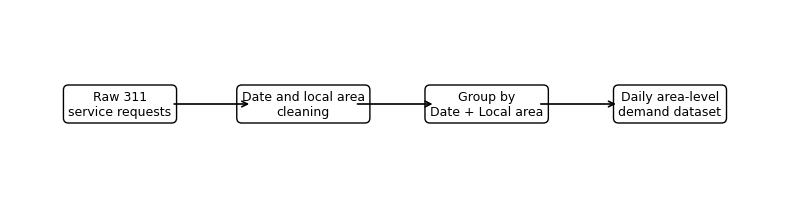

In [16]:
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

steps = [
    "Raw 311\nservice requests",
    "Date and local area\ncleaning",
    "Group by\nDate + Local area",
    "Daily area-level\ndemand dataset"
]

fig, ax = plt.subplots(figsize=(8, 2.2))

x_positions = range(len(steps))

for x, step in zip(x_positions, steps):
    ax.text(
        x,
        0,
        step,
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
    )

for x in range(len(steps) - 1):
    ax.annotate(
        "",
        xy=(x + 0.72, 0),
        xytext=(x + 0.28, 0),
        arrowprops=dict(arrowstyle="->", linewidth=1.2)
    )

ax.set_xlim(-0.6, len(steps) - 0.4)
ax.set_ylim(-0.7, 0.7)
ax.axis("off")

plt.tight_layout()

plt.savefig("figures/preprocessing_pipeline.pdf", bbox_inches="tight")
plt.savefig("figures/preprocessing_pipeline.png", dpi=300, bbox_inches="tight")

plt.show()

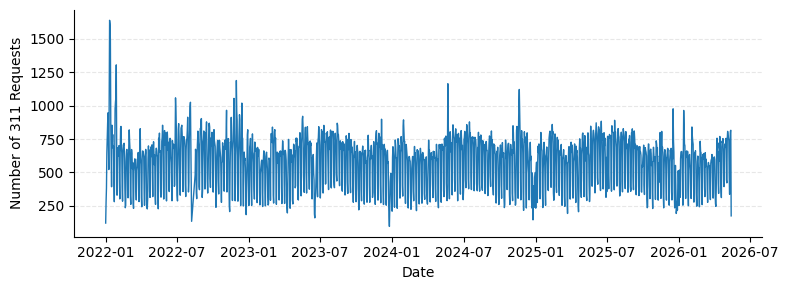

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

df = pd.read_csv("../data/daily_demand.csv")
df["date"] = pd.to_datetime(df["date"])

daily_total = (
    df.groupby("date")["request_count"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(
    daily_total["date"],
    daily_total["request_count"],
    linewidth=1
)

ax.set_xlabel("Date")
ax.set_ylabel("Number of 311 Requests")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("figures/daily_demand_timeseries.pdf", bbox_inches="tight")
plt.savefig("figures/daily_demand_timeseries.png", dpi=300, bbox_inches="tight")

plt.show()

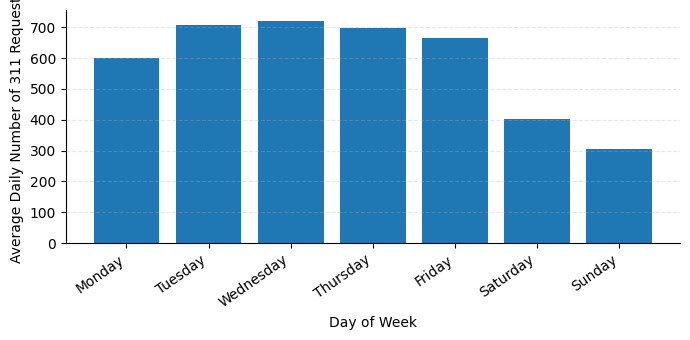

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

# Load aggregated daily area-level demand
df = pd.read_csv("../data/daily_demand.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# --------------------------------------------------
# 1. Sum all 22 areas to get total city-wide
#    demand for each date
# --------------------------------------------------
daily_total = (
    df.groupby("date")["request_count"]
    .sum()
    .reset_index()
)

# --------------------------------------------------
# 2. Extract day of week
# Monday = 0, Sunday = 6
# --------------------------------------------------
daily_total["day_of_week"] = daily_total["date"].dt.dayofweek

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# --------------------------------------------------
# 3. Calculate MEAN daily demand for each weekday
#
# Important: use mean, not sum.
# Otherwise a weekday appearing more often in the
# dataset could have a larger total just because
# it has more observations.
# --------------------------------------------------
weekday_demand = (
    daily_total
    .groupby("day_of_week")["request_count"]
    .mean()
    .reindex(range(7))
)

# --------------------------------------------------
# 4. Create figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.bar(
    day_names,
    weekday_demand.values
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Number of 311 Requests")

# Make labels fit in IEEE figure
plt.xticks(
    rotation=35,
    ha="right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# --------------------------------------------------
# 5. Save high-quality versions
# --------------------------------------------------
plt.savefig(
    "figures/day_of_week_demand.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/day_of_week_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

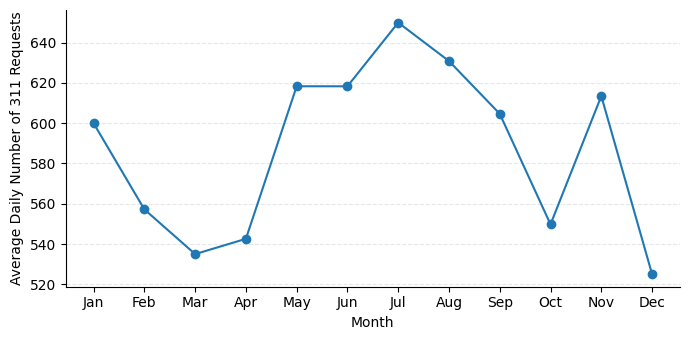

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

# --------------------------------------------------
# 1. Load aggregated daily area-level demand
# --------------------------------------------------
df = pd.read_csv("../data/daily_demand.csv")

df["date"] = pd.to_datetime(df["date"])

# --------------------------------------------------
# 2. Sum across all 22 local areas
#    to get total city-wide demand per date
# --------------------------------------------------
daily_total = (
    df.groupby("date")["request_count"]
    .sum()
    .reset_index()
)

# --------------------------------------------------
# 3. Extract month number
# --------------------------------------------------
daily_total["month"] = daily_total["date"].dt.month

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

# --------------------------------------------------
# 4. Calculate average DAILY city-wide demand
#    for each month across the study period
# --------------------------------------------------
monthly_demand = (
    daily_total
    .groupby("month")["request_count"]
    .mean()
    .reindex(range(1, 13))
)

# --------------------------------------------------
# 5. Create figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(
    month_names,
    monthly_demand.values,
    marker="o",
    linewidth=1.5
)

ax.set_xlabel("Month")
ax.set_ylabel("Average Daily Number of 311 Requests")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# --------------------------------------------------
# 6. Save figure
# --------------------------------------------------
plt.savefig(
    "figures/monthly_demand.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/monthly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

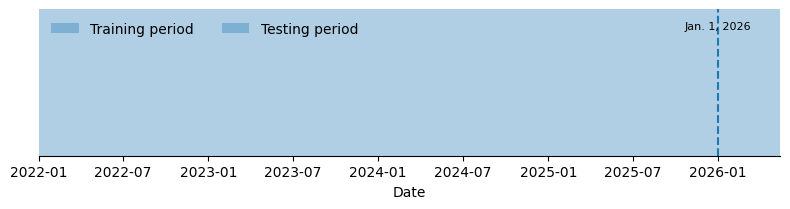

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

# --------------------------------------------------
# 1. Load forecasting dataset
# --------------------------------------------------
df = pd.read_csv("../data/daily_demand.csv")

df["date"] = pd.to_datetime(df["date"])

# --------------------------------------------------
# 2. Get study period
# --------------------------------------------------
start_date = df["date"].min()
end_date = df["date"].max()

# IMPORTANT:
# This must match your actual forecasting split
split_date = pd.Timestamp("2026-01-01")

# --------------------------------------------------
# 3. Create figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 2.2))

# Training period
ax.axvspan(
    start_date,
    split_date,
    alpha=0.35,
    label="Training period"
)

# Testing period
ax.axvspan(
    split_date,
    end_date,
    alpha=0.35,
    label="Testing period"
)

# Split boundary
ax.axvline(
    split_date,
    linestyle="--",
    linewidth=1.5
)

# Label split date
ax.text(
    split_date,
    0.92,
    "Jan. 1, 2026",
    ha="center",
    va="top",
    fontsize=8,
    transform=ax.get_xaxis_transform()
)

# --------------------------------------------------
# 4. Formatting
# --------------------------------------------------
ax.set_xlabel("Date")
ax.set_yticks([])

ax.set_xlim(start_date, end_date)

ax.legend(
    loc="upper left",
    frameon=False,
    ncol=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

# --------------------------------------------------
# 5. Save
# --------------------------------------------------
plt.savefig(
    "figures/train_test_split.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
print(daily_demand["Local area"].nunique())

22


In [46]:
print(
    daily_demand.groupby('date')["request_count"]
    .sum()
    .tail(20)
)

date
2026-04-25    396
2026-04-26    394
2026-04-27    664
2026-04-28    714
2026-04-29    690
2026-04-30    695
2026-05-01    756
2026-05-02    445
2026-05-03    422
2026-05-04    752
2026-05-05    808
2026-05-06    782
2026-05-07    758
2026-05-08    739
2026-05-09    472
2026-05-10    337
2026-05-11    737
2026-05-12    809
2026-05-13    816
2026-05-14    175
Name: request_count, dtype: int64


In [ ]:
# save the new dataset
daily_demand.to_csv(
    "../data/daily_demand.csv",
    index=False
)

In [2]:
daily_demand = pd.read_csv("../data/daily_demand.csv")

In [3]:
print("Start: " + daily_demand["date"].min())
print("End: " + daily_demand["date"].max())

Start: 2022-01-01
End: 2026-05-14


In [4]:
counts = daily_demand.groupby("Local area").size()

print(counts)

Local area
Arbutus Ridge               1583
Downtown                    1587
Dunbar-Southlands           1587
Fairview                    1587
Grandview-Woodland          1587
Hastings-Sunrise            1587
Kensington-Cedar Cottage    1587
Kerrisdale                  1582
Killarney                   1587
Kitsilano                   1587
Marpole                     1587
Mount Pleasant              1587
Oakridge                    1577
Renfrew-Collingwood         1587
Riley Park                  1587
Shaughnessy                 1573
South Cambie                1578
Strathcona                  1587
Sunset                      1587
Victoria-Fraserview         1586
West End                    1587
West Point Grey             1583
dtype: int64


In [5]:
downtown = daily_demand[
    daily_demand["Local area"] == "Downtown"
]

print(downtown.head())

          date Local area  request_count
1   2022-01-01   Downtown             12
21  2022-01-02   Downtown             35
43  2022-01-03   Downtown             51
65  2022-01-04   Downtown             83
87  2022-01-05   Downtown             70


/var/folders/f0/cs68sc7504xgdwhqrdm0sx4h0000gn/T/ipykernel_2333/3597371785.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downtown["date"] = pd.to_datetime(downtown["date"])


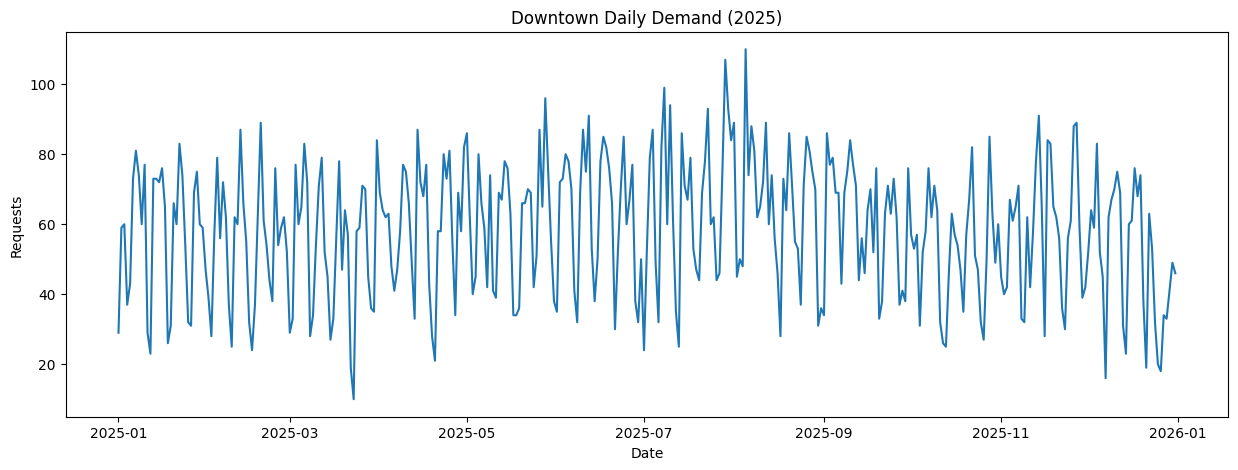

In [16]:
downtown = daily_demand[
    (daily_demand["Local area"] == "Downtown")
]

downtown["date"] = pd.to_datetime(downtown["date"])

downtown_2025 = downtown[
    downtown["date"].dt.year == 2025
]

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(
    downtown_2025["date"],
    downtown_2025["request_count"]
)

plt.title("Downtown Daily Demand (2025)")
plt.xlabel("Date")
plt.ylabel("Requests")
plt.show()

In [15]:
print(
    downtown["date"]
    .dt.year
    .value_counts()
    .sort_index()
)

date
2022    357
2023    365
2024    366
2025    365
2026    134
Name: count, dtype: int64


In [17]:
downtown_2025["day_of_week"] = downtown_2025["date"].dt.day_name()

weekly_pattern = (
    downtown_2025
    .groupby("day_of_week")["request_count"]
    .mean()
)

print(weekly_pattern)

day_of_week
Friday       62.519231
Monday       62.538462
Saturday     39.230769
Sunday       35.211538
Thursday     69.461538
Tuesday      70.038462
Wednesday    69.452830
Name: request_count, dtype: float64


/var/folders/f0/cs68sc7504xgdwhqrdm0sx4h0000gn/T/ipykernel_2333/1513043350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downtown_2025["day_of_week"] = downtown_2025["date"].dt.day_name()


In [18]:
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern = weekly_pattern.reindex(days)

print(weekly_pattern)

day_of_week
Monday       62.538462
Tuesday      70.038462
Wednesday    69.452830
Thursday     69.461538
Friday       62.519231
Saturday     39.230769
Sunday       35.211538
Name: request_count, dtype: float64


/var/folders/f0/cs68sc7504xgdwhqrdm0sx4h0000gn/T/ipykernel_2333/1945622529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downtown_2025["rolling_7"] = (


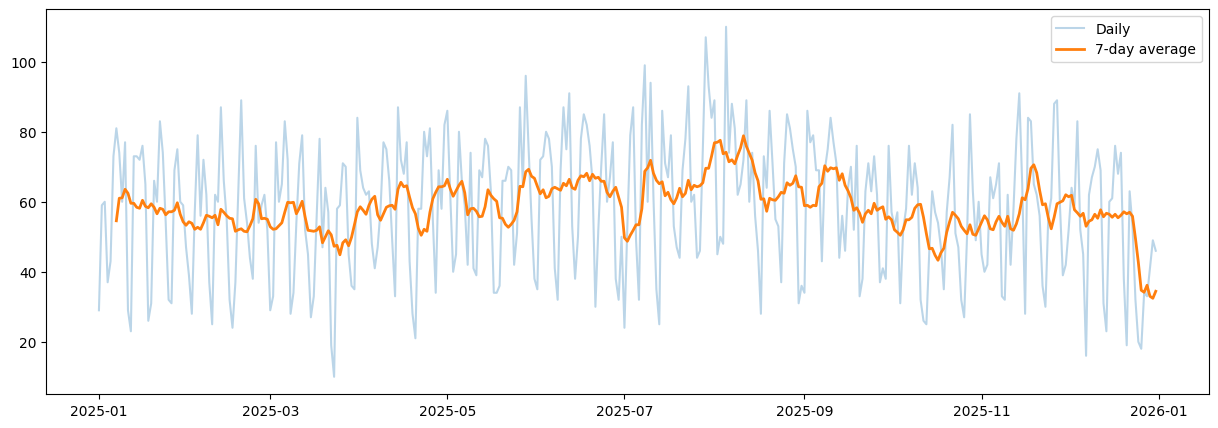

In [19]:
downtown_2025["rolling_7"] = (
    downtown_2025["request_count"]
    .rolling(7)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    downtown_2025["date"],
    downtown_2025["request_count"],
    alpha=0.3,
    label="Daily"
)

plt.plot(
    downtown_2025["date"],
    downtown_2025["rolling_7"],
    linewidth=2,
    label="7-day average"
)

plt.legend()
plt.show()